# 02 · Exploratory Analysis, Cleaning & Transformation
**Process-model steps:** *Explore → Clean → Transform*
**AML concept:** expected activity, red flags, source-data checks
**Statistics (*Practical Statistics* ch. 1 & 2, 7):** robust location & spread, percentiles, distributions & QQ-plots, categorical association, correlation, PCA · **Fraud Analytics ch. 2:** Benford's law, missing values, outliers, red flags, WoE/IV, PCA

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import roc_auc_score
import amlkit as ak

pd.set_option("display.float_format", "{:,.3f}".format); pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")

txn = pd.read_pickle(ak.PROC / "txn_clean.pkl")
kyc = pd.read_pickle(ak.PROC / "kyc_clean.pkl")
truth = ak.load_truth()                       # oracle for grading (lab only)
t = txn.merge(kyc[["customer_id", "segment"]], on="customer_id")
print(t.shape)

(820945, 15)


## 1 · Location and variability — why the mean misleads
Money amounts are heavy-tailed. Compare classic and **robust** estimates (*Practical Statistics* ch. 1). This matters for thresholds: "mean + 2 SD" (one of the "simple ways" in AML ch. 9) is only valid for roughly normal data.

In [2]:
def summary(x):
    return pd.Series({
        "mean": x.mean(), "trimmed mean 10%": stats.trim_mean(x, 0.1), "median": x.median(),
        "std": x.std(), "MAD (scaled)": stats.median_abs_deviation(x, scale="normal"),
        "IQR": x.quantile(.75) - x.quantile(.25), "skew": stats.skew(x), "kurtosis": stats.kurtosis(x)})

t.groupby("channel")["amount_usd"].apply(summary).unstack().round(1)

,mean,trimmed mean 10%,median,std,MAD (scaled),IQR,skew,kurtosis
channel,,,,,,,,
card_online,131.000,96.100,76.400,183.100,69.400,115.800,8.900,269.100
card_pos,79.800,61.600,51.200,97.100,43.100,69.000,5.500,69.700
cash_deposit,"2,231.800","1,608.000","1,258.800","3,210.400","1,189.900","1,969.000",9.100,289.600
cash_withdrawal,"1,028.700",761.900,610.400,"1,362.600",552.300,906.500,5.200,55.400
transfer_in,"1,741.300","1,152.700",860.300,"3,014.800",842.600,"1,487.500",8.500,156.900
transfer_out,"1,578.600","1,058.800",788.700,"2,661.700",777.900,"1,378.700",8.100,137.800
wire_in,"14,480.600","9,782.000","7,215.300","23,968.400","7,377.100","13,213.700",7.800,142.900
wire_out,"13,011.500","8,735.800","6,487.100","21,356.400","6,630.600","11,696.800",6.500,79.900


In [3]:
pct = t.groupby("segment")["amount_usd"].quantile([.5, .9, .99, .999]).unstack()
pct.columns = ["p50", "p90", "p99", "p99.9"]
pct

,p50,p90,p99,p99.9
segment,,,,
cash_intensive,808.700,"4,502.760","17,943.270","53,631.443"
corporate,"3,362.420","23,144.729","88,427.054","218,524.914"
retail_salaried,161.770,"1,192.884","4,818.147","13,305.669"
retail_self_employed,274.290,"1,841.196","7,832.528","28,162.965"
small_business,715.390,"4,621.692","20,725.885","60,500.046"


### Visual exploration: distributions by channel / segment (log scale)

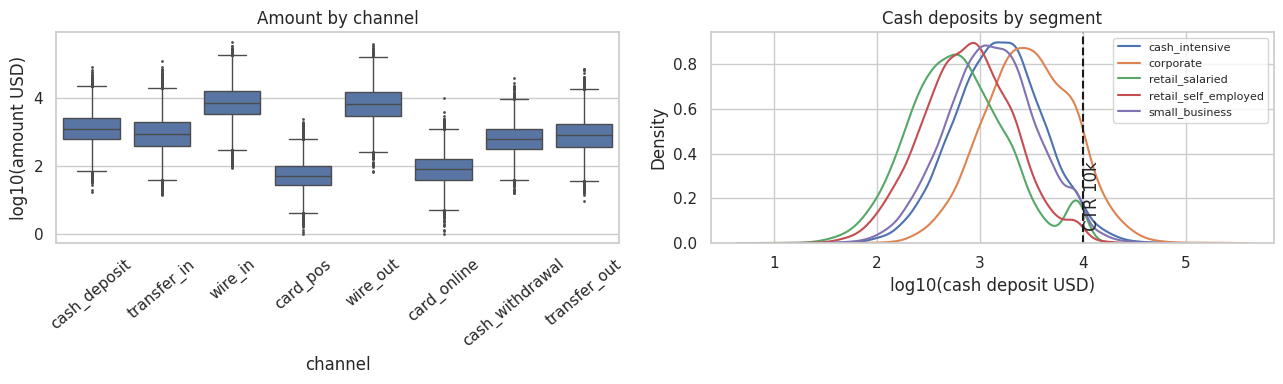

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.boxplot(data=t.sample(150_000, random_state=1), x="channel", y=np.log10(t.sample(150_000, random_state=1).amount_usd),
            ax=ax[0], fliersize=1)
ax[0].set(ylabel="log10(amount USD)", title="Amount by channel"); ax[0].tick_params(axis="x", rotation=40)

cd = t[t.channel == "cash_deposit"]
for s, g in cd.groupby("segment"):
    sns.kdeplot(np.log10(g.amount_usd), ax=ax[1], label=s, bw_adjust=1.2)
ax[1].axvline(np.log10(ak.CTR_THRESHOLD), color="k", ls="--"); ax[1].text(np.log10(ak.CTR_THRESHOLD), 0.05, " CTR 10k", rotation=90)
ax[1].set(xlabel="log10(cash deposit USD)", title="Cash deposits by segment"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

**QQ-plots**: raw amounts are far from normal; log-amounts are close to it (long-tailed, ~lognormal). Tail behaviour is what thresholds sit on.

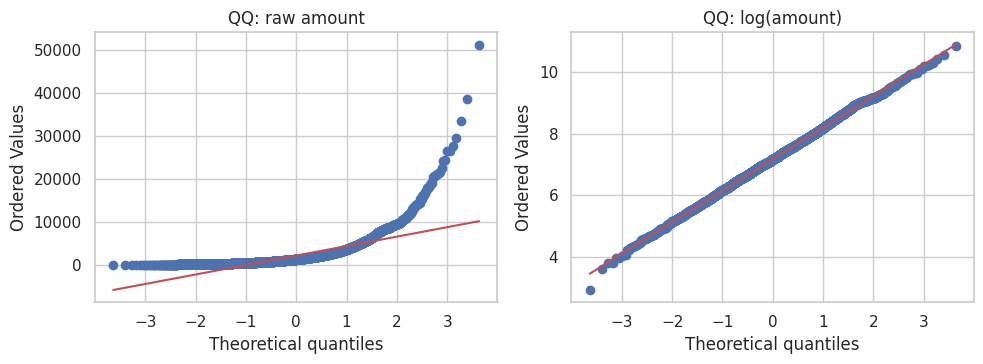

In [5]:
x = cd.loc[cd.segment == "small_business", "amount_usd"].sample(5000, random_state=1)
fig, ax = plt.subplots(1, 2, figsize=(10, 3.8))
stats.probplot(x, plot=ax[0]); ax[0].set_title("QQ: raw amount")
stats.probplot(np.log(x), plot=ax[1]); ax[1].set_title("QQ: log(amount)")
plt.tight_layout(); plt.show()

## 2 · Categorical exploration and association
Do segments use channels differently? Chi-square test of independence + **effect size** (Cramér's V). With 800 k rows *everything* is "significant", so effect size is what matters (*Practical Statistics*: practical vs statistical significance).

chi2=259,250  dof=28  p=0.00e+00  Cramer's V=0.281


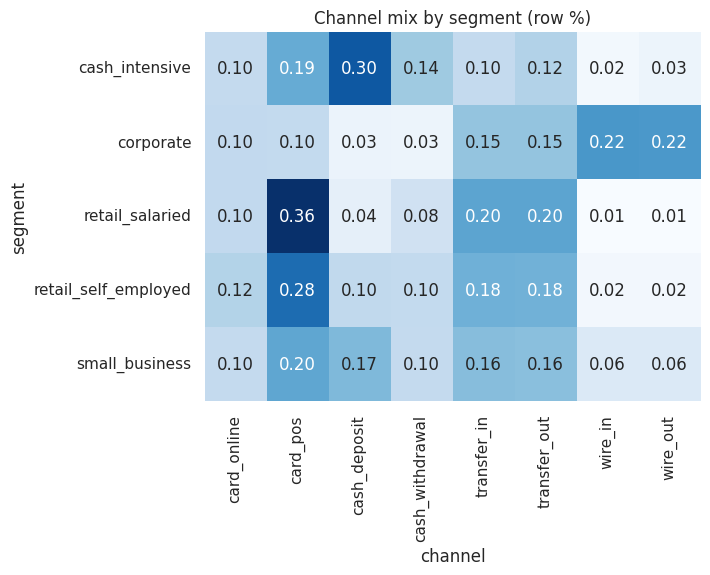

In [6]:
ct = pd.crosstab(t.segment, t.channel)
chi2, p, dof, _ = stats.chi2_contingency(ct)
cramers_v = np.sqrt(chi2 / (ct.values.sum() * (min(ct.shape) - 1)))
print(f"chi2={chi2:,.0f}  dof={dof}  p={p:.2e}  Cramer's V={cramers_v:.3f}")
sns.heatmap(ct.div(ct.sum(axis=1), axis=0), annot=True, fmt=".2f", cmap="Blues", cbar=False)
plt.title("Channel mix by segment (row %)"); plt.show()

## 3 · Correlation and two-variable views
Customer-level activity: number of transactions vs total value. Prefer **Spearman** for skewed data.

Pearson  n_txn~total : 0.7
Spearman n_txn~total : 0.865


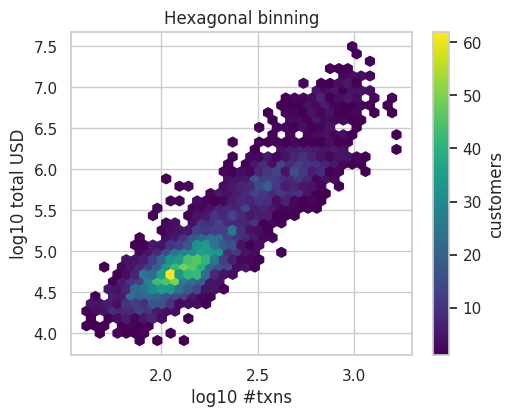

In [7]:
cust = t.groupby("customer_id").agg(n_txn=("txn_id", "size"), total=("amount_usd", "sum"), mean_amt=("amount_usd", "mean"))
print("Pearson  n_txn~total :", round(cust.n_txn.corr(cust.total), 3))
print("Spearman n_txn~total :", round(cust.n_txn.corr(cust.total, method="spearman"), 3))
fig, ax = plt.subplots(figsize=(5.5, 4.2))
hb = ax.hexbin(np.log10(cust.n_txn), np.log10(cust.total), gridsize=35, cmap="viridis", mincnt=1)
plt.colorbar(hb, label="customers"); ax.set(xlabel="log10 #txns", ylabel="log10 total USD", title="Hexagonal binning")
plt.show()

## 4 · Benford's law (Fraud Analytics ch. 2)
In many naturally occurring amounts the leading digit *d* appears with probability log₁₀(1 + 1/d) (1 ≈ 30 %, 9 ≈ 4.6 %). Human-fabricated or **structured** amounts break this. Test with a chi-square goodness-of-fit and Nigrini's **MAD** conformity score. Screening tool only — legitimate data with a narrow range also fails.

All cash deposits: n=99763  MAD=0.0041  (Nigrini: <0.006 close, 0.006-0.012 acceptable, 0.012-0.015 marginal, >0.015 non-conformity)


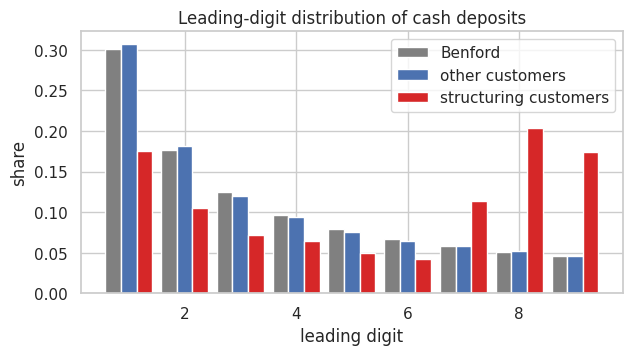

In [8]:
BEN = np.log10(1 + 1 / np.arange(1, 10))

def first_digit(x):
    x = np.asarray(x, float); x = x[x > 0]
    return (x / 10 ** np.floor(np.log10(x))).astype(int)

def benford_test(x):
    d = first_digit(x); n = len(d)
    obs = np.bincount(d, minlength=10)[1:]
    chi2, p = stats.chisquare(obs, BEN * n)
    mad = np.mean(np.abs(obs / n - BEN))
    return pd.Series(dict(n=n, chi2=chi2, p=p, mad=mad))

overall = benford_test(cd.amount_usd)
print("All cash deposits: n=%d  MAD=%.4f  (Nigrini: <0.006 close, 0.006-0.012 acceptable, 0.012-0.015 marginal, >0.015 non-conformity)" % (overall.n, overall.mad))

# structuring customers (oracle) versus everyone else
s_ids = truth[truth.typology == "structuring"].customer_id
fig, ax = plt.subplots(figsize=(7, 3.4))
w = 0.28; k = np.arange(1, 10)
ax.bar(k - w, BEN, w, label="Benford", color="grey")
ax.bar(k, np.bincount(first_digit(cd[~cd.customer_id.isin(s_ids)].amount_usd), minlength=10)[1:] / len(cd[~cd.customer_id.isin(s_ids)]), w, label="other customers")
ax.bar(k + w, np.bincount(first_digit(cd[cd.customer_id.isin(s_ids)].amount_usd), minlength=10)[1:] / len(cd[cd.customer_id.isin(s_ids)]), w, label="structuring customers", color="tab:red")
ax.set(xlabel="leading digit", ylabel="share", title="Leading-digit distribution of cash deposits"); ax.legend(); plt.show()

**Customer-level Benford screen.** One test per customer = hundreds of tests → expect false alarms by chance alone (multiple comparisons, *Practical Statistics* ch. 3). Apply Benjamini-Hochberg FDR control and grade the screen with the oracle.

In [9]:
from statsmodels.stats.multitest import multipletests
per = cd.groupby("customer_id").amount_usd.apply(benford_test).unstack()
per = per[per.n >= 40].copy()
per["p_bh"] = multipletests(per.p, method="fdr_bh")[1]
per = per.join(truth.set_index("customer_id")[["is_launderer", "typology"]])
print("customers tested:", len(per), "| raw p<0.05:", (per.p < .05).sum(), "| BH q<0.05:", (per.p_bh < .05).sum())
print("AUC of MAD as a launderer score: %.3f" % roc_auc_score(per.is_launderer, per.mad))
per.assign(flag=per.p_bh < .05).groupby("typology").flag.agg(["sum", "count"]).rename(columns={"sum": "flagged", "count": "tested"})

customers tested: 684 | raw p<0.05: 81 | BH q<0.05: 53
AUC of MAD as a launderer score: 0.716


,flagged,tested
typology,,
commingling,0,14
mule_ring,0,12
none,3,596
pass_through,0,7
smurfing_low,17,19
structuring,33,36


Benford flags the two **cash-structuring** typologies well (`structuring` deposits cluster at 7,500-9,900, `smurfing_low` at 1,800-2,450 — leading digits 7-9 and 1-2 are over-represented) but is blind to commingling, mule rings and pass-through — a useful, cheap *red-flag generator*, not a detector.

## 5 · Missing values
First ask *why* they are missing (MCAR / MAR / MNAR); then decide.

In [10]:
miss = kyc[["tenure_years", "declared_monthly_turnover"]].isna().mean().to_frame("share_missing"); print(miss)

vol = txn.groupby("customer_id").amount_usd.sum().reindex(kyc.customer_id).values
m = kyc.declared_monthly_turnover.isna().values
u = stats.mannwhitneyu(vol[m], vol[~m])
print(f"Is missing-turnover related to customer volume?  median {np.median(vol[m]):,.0f} vs {np.median(vol[~m]):,.0f}, Mann-Whitney p = {u.pvalue:.2f}")
print("-> consistent with MCAR here; in a real bank KYC gaps are often MNAR (e.g. high-risk clients supply less) so test by segment/region too.")

                           share_missing
tenure_years                       0.039
declared_monthly_turnover          0.052
Is missing-turnover related to customer volume?  median 84,269 vs 84,818, Mann-Whitney p = 0.69
-> consistent with MCAR here; in a real bank KYC gaps are often MNAR (e.g. high-risk clients supply less) so test by segment/region too.


## 6 · Outliers — four methods, one variable
Monthly credits per customer (log scale is the natural scale). Compare a classic z-score, a **robust** z-score (median/MAD), the IQR fence and a percentile cut-off.

In [11]:
feat = ak.build_customer_features(txn, kyc)
feat = feat.merge(truth[["customer_id", "is_launderer", "typology"]], on="customer_id")

x = np.log10(feat.monthly_credits.clip(lower=1))
z = (x - x.mean()) / x.std()
rz = 0.6745 * (x - x.median()) / stats.median_abs_deviation(x)
q1, q3 = x.quantile([.25, .75]); iqr = q3 - q1
methods = {
    "z-score |z|>3 (log)": z.abs() > 3,
    "robust z >3.5 (log)": rz.abs() > 3.5,
    "IQR fence 1.5x (log)": (x < q1 - 1.5 * iqr) | (x > q3 + 1.5 * iqr),
    "top 1% (percentile)": x > x.quantile(.99),
    "z-score |z|>3 (RAW $)": ((feat.monthly_credits - feat.monthly_credits.mean()) / feat.monthly_credits.std()).abs() > 3,
}
res = pd.DataFrame({k: dict(flagged=int(v.sum()), launderers_flagged=int(feat.is_launderer[v].sum()),
                            precision=feat.is_launderer[v].mean() if v.sum() else np.nan) for k, v in methods.items()}).T
res

,flagged,launderers_flagged,precision
z-score |z|>3 (log),10.000,0.000,0.000
robust z >3.5 (log),94.000,5.000,0.053
IQR fence 1.5x (log),44.000,2.000,0.045
top 1% (percentile),35.000,2.000,0.057
z-score |z|>3 (RAW $),94.000,5.000,0.053


Note how the *raw-dollar* z-score picks the biggest corporates (large ≠ suspicious) — a **global** outlier rule ignores peer group. That is why AML ch. 8 segments customers before setting thresholds; we test peer-group outliers in notebook 03.

## 7 · Red flags (Fraud Analytics ch. 2)
Simple binary indicators encode expert knowledge; they later become model inputs and analyst-friendly reasons. Measure each flag's *hit rate*, *precision* and *lift* (lab: against the oracle).

In [12]:
flags = pd.DataFrame({
    "rf_near_ctr":     feat.near_ctr_cnt >= 3,              # repeated deposits just below reporting threshold
    "rf_cash_burst":   feat.max_cash_agg_5d >= ak.CTR_THRESHOLD,
    "rf_turnover_3x":  feat.turnover_ratio > 3,             # activity >> declared
    "rf_flowthrough":  feat.flowthrough_max >= 0.9,         # money in ~= money out, large volume
    "rf_high_risk_cty": feat.hr_share > 0.05,
    "rf_pep":          feat.is_pep == 1,
})
base = feat.is_launderer.mean()
rep = pd.DataFrame({c: dict(hit_rate=flags[c].mean(), precision=feat.is_launderer[flags[c]].mean(),
                            lift=feat.is_launderer[flags[c]].mean() / base, recall=flags[c][feat.is_launderer == 1].mean())
                    for c in flags}).T
print(f"base rate = {base:.3f}"); rep

base rate = 0.035


,hit_rate,precision,lift,recall
rf_near_ctr,0.078,0.241,6.854,0.537
rf_cash_burst,0.230,0.124,3.530,0.813
rf_turnover_3x,0.013,0.644,18.338,0.236
rf_flowthrough,0.155,0.105,2.987,0.463
rf_high_risk_cty,0.210,0.053,1.512,0.317
rf_pep,0.008,0.034,0.981,0.008


In [13]:
feat["n_flags"] = flags.sum(axis=1)
feat.groupby("n_flags").is_launderer.agg(customers="size", launderers="sum", rate="mean")

,customers,launderers,rate
n_flags,,,
0,2251,9,0.004
1,535,11,0.021
2,328,45,0.137
3,306,42,0.137
4,78,15,0.192
5,2,1,0.500


## 8 · Missing-value treatment & transformation

**Rules used below** (document each one!):
* segment-median imputation + a **missing-indicator** column (the fact that it was missing may itself be informative)
* `log1p` for heavy-tailed amounts, `RobustScaler` / `StandardScaler` for distance- or gradient-based methods
* quantile binning + **Weight of Evidence** for scorecards / variable screening

In [14]:
for c in ["tenure_years", "declared_monthly_turnover"]:
    feat[f"{c}_missing"] = feat[c].isna().astype(int)
    feat[c] = feat[c].fillna(feat.groupby("segment")[c].transform("median"))
feat["turnover_ratio"] = feat["monthly_credits"] / feat["declared_monthly_turnover"]
print("remaining NaN:", int(feat[["tenure_years", "declared_monthly_turnover", "turnover_ratio"]].isna().sum().sum()))

heavy = ["n_txn", "total_amt", "mean_amt", "max_amt", "credits", "debits", "amt_cash_deposit", "amt_wire_in", "max_cash_agg_5d",
         "monthly_credits", "turnover_ratio", "n_counterparties", "hr_amt"]
for c in heavy:
    feat[f"log_{c}"] = np.log1p(feat[c])
print("skewness before -> after log1p")
print(pd.DataFrame({"raw": feat[heavy].apply(stats.skew), "log1p": feat[[f"log_{c}" for c in heavy]].apply(stats.skew).values}).round(2).T)

remaining NaN: 0
skewness before -> after log1p
       n_txn  total_amt  mean_amt  max_amt  credits  debits  amt_cash_deposit  \
raw    2.360      6.310     4.920    5.730    6.080   6.580             5.360   
log1p  0.720      1.040     1.070    0.730    0.910   1.100            -0.580   

       amt_wire_in  max_cash_agg_5d  monthly_credits  turnover_ratio  \
raw          6.440            4.040            6.080          23.290   
log1p       -0.830           -1.210            0.910           2.670   

       n_counterparties  hr_amt  
raw               3.750   6.620  
log1p             1.310   0.320  


### Weight of Evidence and Information Value
WoE = ln(%good / %bad) per bin, IV = Σ (%good − %bad)·WoE. Rule of thumb: IV < 0.02 useless · 0.02–0.1 weak · 0.1–0.3 medium · 0.3–0.5 strong · > 0.5 suspiciously strong (check for leakage!). ⚠ Lab caveats: (1) the label here is the *oracle*; with real data it is 'STR filed', which exists only for alerted customers (selection bias). (2) Many IVs exceed 0.5 because the planted typologies are easy to see; on real data expect most IVs below 0.3 and treat > 0.5 as a leakage alarm.

In [15]:
def woe_iv(x, y, bins=8):
    d = pd.DataFrame({"x": x, "y": y})
    try:
        d["bin"] = pd.qcut(d.x, bins, duplicates="drop")
    except ValueError:
        d["bin"] = d.x
    g = d.groupby("bin", observed=True).y.agg(bad="sum", n="count")
    g["good"] = g.n - g.bad
    k = len(g)
    g["pct_bad"] = (g.bad + 0.5) / (g.bad.sum() + 0.5 * k)          # 0.5 smoothing avoids log(0)
    g["pct_good"] = (g.good + 0.5) / (g.good.sum() + 0.5 * k)
    g["woe"] = np.log(g.pct_good / g.pct_bad)
    g["iv"] = (g.pct_good - g.pct_bad) * g.woe
    return g, g.iv.sum()

cands = ["turnover_ratio", "near_ctr_cnt", "max_cash_agg_5d", "flowthrough_max", "hr_share", "night_share", "n_counterparties",
         "tenure_years", "mean_amt", "cash_share_credits", "n_txn"]
iv = pd.Series({c: woe_iv(feat[c], feat.is_launderer)[1] for c in cands}).sort_values(ascending=False)
iv.to_frame("IV").assign(strength=pd.cut(iv, [-1, .02, .1, .3, .5, 99], labels=["useless", "weak", "medium", "strong", "suspicious"]))

,IV,strength
mean_amt,2.331,suspicious
cash_share_credits,1.850,suspicious
max_cash_agg_5d,1.773,suspicious
near_ctr_cnt,1.308,suspicious
turnover_ratio,0.983,suspicious
n_counterparties,0.944,suspicious
n_txn,0.794,suspicious
flowthrough_max,0.748,suspicious
night_share,0.217,medium
hr_share,0.178,medium


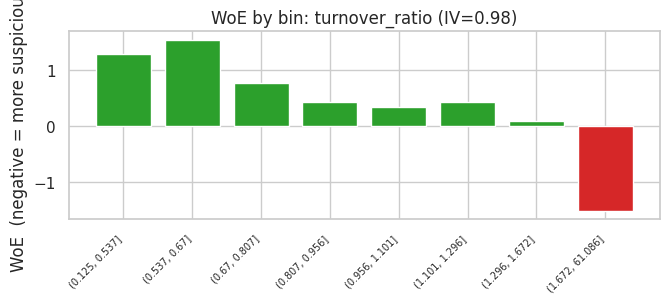

In [16]:
g, ivv = woe_iv(feat.turnover_ratio, feat.is_launderer)
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.bar(range(len(g)), g.woe, color=np.where(g.woe < 0, "tab:red", "tab:green"))
ax.set_xticks(range(len(g))); ax.set_xticklabels([str(i) for i in g.index], rotation=45, ha="right", fontsize=7)
ax.set(title=f"WoE by bin: turnover_ratio (IV={ivv:.2f})", ylabel="WoE  (negative = more suspicious)"); plt.tight_layout(); plt.show()

## 9 · PCA — compress correlated behaviour (*Practical Statistics* ch. 7; Fraud Analytics ch. 2)
Always standardise first, otherwise the variable with the biggest units dominates.

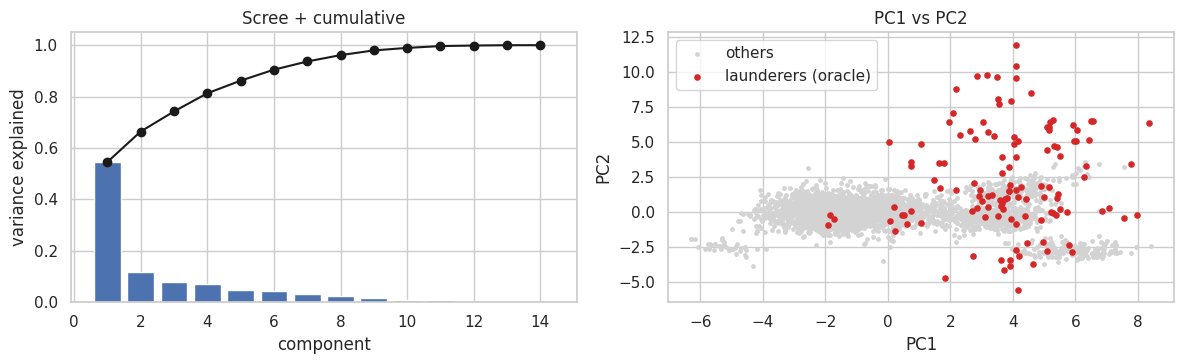

,PC1,PC2,PC3
log_n_txn,0.330,-0.070,-0.130
log_mean_amt,0.330,-0.110,0.080
log_credits,0.350,-0.070,-0.000
log_debits,0.340,-0.150,-0.030
log_amt_cash_deposit,0.320,0.240,-0.160
log_amt_wire_in,0.270,-0.180,0.020
log_max_cash_agg_5d,0.300,0.260,-0.130
log_turnover_ratio,0.080,0.260,0.750
log_n_counterparties,0.310,-0.260,-0.020
cash_share_credits,0.150,0.600,-0.190


In [17]:
pca_cols = [f"log_{c}" for c in ["n_txn", "mean_amt", "credits", "debits", "amt_cash_deposit", "amt_wire_in", "max_cash_agg_5d",
                                 "turnover_ratio", "n_counterparties"]] + ["cash_share_credits", "hr_share", "night_share", "flowthrough_max", "near_ctr_cnt"]
X = StandardScaler().fit_transform(feat[pca_cols])
pca = PCA().fit(X)
ev = pca.explained_variance_ratio_
fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
ax[0].bar(range(1, len(ev) + 1), ev); ax[0].plot(range(1, len(ev) + 1), ev.cumsum(), "o-", color="k")
ax[0].set(xlabel="component", ylabel="variance explained", title="Scree + cumulative")
Z = pca.transform(X)
ax[1].scatter(Z[:, 0], Z[:, 1], s=6, c="lightgrey", label="others")
mk = feat.is_launderer.values == 1
ax[1].scatter(Z[mk, 0], Z[mk, 1], s=14, c="tab:red", label="launderers (oracle)")
ax[1].set(xlabel="PC1", ylabel="PC2", title="PC1 vs PC2"); ax[1].legend(); plt.tight_layout(); plt.show()
load = pd.DataFrame(pca.components_[:3].T, index=pca_cols, columns=["PC1", "PC2", "PC3"]); load.round(2)

## 10 · Persist the analysis table
Best practice: one **feature table** with a documented definition per column (feature dictionary), reused by notebooks 03–08.

In [18]:
feat_out = feat.copy()
feat_out.to_pickle(ak.PROC / "features.pkl")
print(feat_out.shape, "columns saved ->", ak.PROC / "features.pkl")
print("labels (oracle) present in this table are for GRADING only:", [c for c in feat_out.columns if c in ("is_launderer", "typology")])

(3500, 54) columns saved -> /home/claude/aml_fraud_notebooks/data/processed/features.pkl
labels (oracle) present in this table are for GRADING only: ['is_launderer', 'typology']


### Checklist before moving on
- [ ] Robust statistics used where distributions are heavy-tailed
- [ ] Each transformation documented and **fitted on training data only** when used in models (avoid leakage – notebook 06)
- [ ] Red flags reviewed with investigators; hit-rates and precision recorded
- [ ] Multiple-testing correction used whenever you ran one test per customer

**Next → `03_descriptive_analytics`**